In [6]:
import os
import glob
pattern = os.path.join("..", "data", "query-results-raw-*.json")
files = glob.glob(pattern)

if not files:
    print("Error: No data files found matching the pattern.")
    raise ValueError("No matching data files found.")


KeyError: 'query-cache-m'

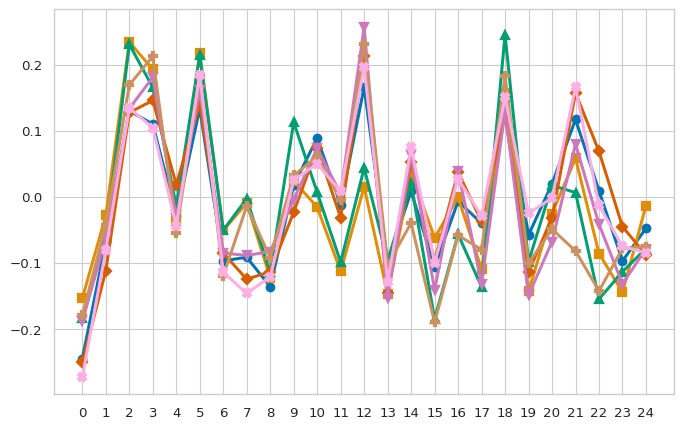

In [20]:
import json
import os
from typing import List, Tuple, Dict, Any
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.lines as mlines
import matplotlib.ticker as ticker

def extract_cache_stats(entry: Dict[str, Any]) -> Tuple[int, int]:
    """Extracts hit and total counts from the cache state JSON string."""
    cache_str = entry.get("@comunica/persistent-cache-manager:sourceState") or \
                entry.get("@comunica/persistent-cache-manager:sourceStateQuerySource")

    if not cache_str:
        return 0, 0

    try:
        cache_stats = json.loads(cache_str)
        hits = cache_stats.get("hits", 0)
        total = hits + cache_stats.get("misses", 0)
        return hits, total
    except json.JSONDecodeError:
        return 0, 0

def extract_eviction_percentage(entry: Dict[str, Any]) -> float:
    """Extracts the eviction percentage from the cache state JSON string."""
    cache_str = entry.get("@comunica/persistent-cache-manager:sourceState") or \
                entry.get("@comunica/persistent-cache-manager:sourceStateQuerySource")

    if not cache_str:
        return np.nan

    try:
        cache_stats = json.loads(cache_str)
        if "evictionPercentage" in cache_stats:
            return float(cache_stats["evictionPercentage"])
        return np.nan
    except (json.JSONDecodeError, ValueError, TypeError):
        return np.nan

def apply_min_support(df: pd.DataFrame, depth_col: str, value_col: str, min_support: int) -> pd.DataFrame:
    """
    Aggregates data by depth and algorithm, filtering out depths
    where the number of observations falls below min_support.
    """
    if df.empty:
        return pd.DataFrame()

    # Aggregate to compute both mean and observation count
    agg_df = df.groupby(['algorithm', depth_col])[value_col].agg(['mean', 'count']).reset_index()

    # Filter out depths lacking sufficient support
    valid_df = agg_df[agg_df['count'] >= min_support]

    if valid_df.empty:
        return pd.DataFrame()

    # Pivot for output
    pivot_df = valid_df.pivot(index=depth_col, columns='algorithm', values='mean').reset_index()
    pivot_df.columns.name = None

    return pivot_df

def calculate_depth_hit_rates(filenames: List[str], min_support: int = 1) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Parses result files to calculate average hit rates, filtering by minimum support."""
    records = []

    for path in sorted(filenames):
        algo_label = os.path.basename(path).replace("query-results-raw-", "").replace(".json", "")

        with open(path, 'r') as file:
            data = json.load(file)

        prev_session_id = None
        session_depth = 0

        for entry in data:
            sequence_depth_str = entry.get("id")
            if sequence_depth_str is None:
                continue

            sequence_depth = int(sequence_depth_str)

            seq_element = entry.get("sequenceElement", {})
            session_info = seq_element.get("session", {})
            current_session_id = session_info.get("sessionId")

            if current_session_id is None:
                continue

            if current_session_id != prev_session_id:
                session_depth = 1
            else:
                session_depth += 1

            hits, total = extract_cache_stats(entry)

            if total > 0:
                records.append({
                    'algorithm': algo_label,
                    'sequence_depth': sequence_depth,
                    'session_depth': session_depth,
                    'hit_rate': hits / total
                })

            prev_session_id = current_session_id

    df = pd.DataFrame(records)
    session_pivot = apply_min_support(df, 'session_depth', 'hit_rate', min_support)
    sequence_pivot = apply_min_support(df, 'sequence_depth', 'hit_rate', min_support)

    return session_pivot, sequence_pivot

def calculate_depth_eviction_rates(filenames: List[str], min_support: int = 1) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Parses result files to calculate average cache eviction percentages, filtering by minimum support."""
    records = []

    for path in sorted(filenames):
        algo_label = os.path.basename(path).replace("query-results-raw-", "").replace(".json", "")

        with open(path, 'r') as file:
            data = json.load(file)

        prev_session_id = None
        session_depth = 0

        for entry in data:
            sequence_depth_str = entry.get("id")
            if sequence_depth_str is None:
                continue

            sequence_depth = int(sequence_depth_str)

            seq_element = entry.get("sequenceElement", {})
            session_info = seq_element.get("session", {})
            current_session_id = session_info.get("sessionId")

            if current_session_id is None:
                continue

            if current_session_id != prev_session_id:
                session_depth = 1
            else:
                session_depth += 1

            eviction_pct = extract_eviction_percentage(entry)

            if not np.isnan(eviction_pct):
                records.append({
                    'algorithm': algo_label,
                    'sequence_depth': sequence_depth,
                    'session_depth': session_depth,
                    'eviction_percentage': eviction_pct
                })

            prev_session_id = current_session_id

    df = pd.DataFrame(records)
    session_pivot = apply_min_support(df, 'session_depth', 'eviction_percentage', min_support)
    sequence_pivot = apply_min_support(df, 'sequence_depth', 'eviction_percentage', min_support)

    return session_pivot, sequence_pivot

def plot_combined_depth_metrics(hit_df: pd.DataFrame, evict_df: pd.DataFrame, depth_col: str, save_name: str, save_path: str = "."):
    """
    Merges hit rate and eviction dataframes into a long format and generates
    a point plot mapping hit rates to solid lines and eviction percentages to dashed lines.
    """
    if hit_df.empty or evict_df.empty:
        print(f"Insufficient data for plotting {depth_col}.")
        return

    if not os.path.exists(save_path):
        os.makedirs(save_path)

    # Convert wide data back to long data for Seaborn
    hit_melted = hit_df.melt(id_vars=[depth_col], var_name='algorithm', value_name='Value')
    hit_melted['Metric'] = 'Hit Rate'

    evict_melted = evict_df.melt(id_vars=[depth_col], var_name='algorithm', value_name='Value')
    evict_melted['Metric'] = 'Eviction Percentage'

    # Combine datasets
    combined_df = pd.concat([hit_melted, evict_melted], ignore_index=True)
    combined_df['Value'] = pd.to_numeric(combined_df['Value'], errors='coerce')
    combined_df = combined_df.dropna(subset=['Value'])

    # Apply target styling constraints
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

    algorithm_order = sorted(combined_df['algorithm'].unique().tolist())
    colors = sns.color_palette("colorblind", n_colors=len(algorithm_order))
    style_markers = ["o", "s", "^", "D", "v", "P", "X"]

    plt.figure(figsize=(8, 5))
    ax = plt.gca()

    # Hit Rate (Solid lines)
    sns.pointplot(
        data=combined_df[combined_df['Metric'] == 'Hit Rate'],
        x=depth_col, y="Value",
        hue="algorithm", hue_order=algorithm_order,
        palette="colorblind",
        markers=style_markers[:len(algorithm_order)],
        linestyles=["-"] * len(algorithm_order),
        ax=ax, errorbar=None, legend=False
    )

    # Eviction Percentage (Dashed lines)
    sns.pointplot(
        data=combined_df[combined_df['Metric'] == 'Eviction Percentage'],
        x=depth_col, y="Value",
        hue="algorithm", hue_order=algorithm_order,
        palette="colorblind",
        markers=style_markers[:len(algorithm_order)],
        linestyles=["--"] * len(algorithm_order),
        ax=ax, errorbar=None, legend=False
    )

    # Formatting axes
    x_label = "Sequence Depth" if depth_col == "sequence_depth" else "Session Depth"
    ax.set_xlabel(x_label, fontsize=12)
    ax.set_ylabel("Metric Value", fontsize=12)

    # Format Y-axis as percentages
    ax.set_ylim(bottom=0, top=1.05)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'{y:.0%}'))

    # Build Custom Legend
    custom_handles = [
        mlines.Line2D([], [], color='black', linestyle='-', label='Hit Rate (Solid)'),
        mlines.Line2D([], [], color='black', linestyle='--', label='Eviction % (Dashed)')
    ]
    custom_labels = ['Hit Rate (Solid)', 'Eviction % (Dashed)']

    for i, alg in enumerate(algorithm_order):
        c = colors[i]
        m = style_markers[i % len(style_markers)]
        custom_handles.append(mlines.Line2D([], [], color=c, marker=m, linestyle='', markersize=8))
        custom_labels.append(alg)

    # Place legend horizontally above the plot
    plt.legend(handles=custom_handles, labels=custom_labels,
               loc='lower center', bbox_to_anchor=(0.5, 1.05),
               ncol=3, frameon=True, edgecolor='black', fontsize=11)

    plt.tight_layout()

    save_target = os.path.join(save_path, save_name)
    plt.savefig(save_target, bbox_inches='tight')
    print(f"Saved: {save_target}")
    plt.show()

# Execution Pipeline
session_depth_df, sequence_depth_df = calculate_depth_hit_rates(files, min_support=20)
session_depth_df_evict, sequence_depth_df_evict = calculate_depth_eviction_rates(files, min_support=20)

# Display DataFrames
display(session_depth_df)
display(sequence_depth_df)
display(session_depth_df_evict)
display(sequence_depth_df_evict)

# Generate Plots
plot_combined_depth_metrics(
    session_depth_df, session_depth_df_evict,
    depth_col="session_depth", save_name="session_depth_metrics.pdf"
)
plot_combined_depth_metrics(
    sequence_depth_df, sequence_depth_df_evict,
    depth_col="sequence_depth", save_name="sequence_depth_metrics.pdf"
)

In [ ]:
import json
import os
from typing import List, Tuple, Dict, Any
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.lines as mlines

# [Keep extract_cache_stats from the previous code]
def extract_cache_stats(entry: Dict[str, Any]) -> Tuple[int, int]:
    cache_str = entry.get("@comunica/persistent-cache-manager:sourceState") or \
                entry.get("@comunica/persistent-cache-manager:sourceStateQuerySource")
    if not cache_str: return 0, 0
    try:
        cache_stats = json.loads(cache_str)
        hits = cache_stats.get("hits", 0)
        total = hits + cache_stats.get("misses", 0)
        return hits, total
    except json.JSONDecodeError:
        return 0, 0

def apply_min_support(df: pd.DataFrame, depth_col: str, value_col: str, min_support: int) -> pd.DataFrame:
    if df.empty: return pd.DataFrame()
    agg_df = df.groupby(['algorithm', depth_col])[value_col].agg(['mean', 'count']).reset_index()
    valid_df = agg_df[agg_df['count'] >= min_support]
    if valid_df.empty: return pd.DataFrame()
    pivot_df = valid_df.pivot(index=depth_col, columns='algorithm', values='mean').reset_index()
    pivot_df.columns.name = None
    return pivot_df

def calculate_normalized_depth_hit_rates(filenames: List[str], min_support: int = 1) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Calculates hit rate DELTAS (actual - template baseline) to isolate
    the effect of sequence/session depth from template variance.
    """
    records = []

    for path in sorted(filenames):
        algo_label = os.path.basename(path).replace("query-results-raw-", "").replace(".json", "")

        with open(path, 'r') as file:
            data = json.load(file)

        prev_session_id = None
        session_depth = 0

        for entry in data:
            sequence_depth_str = entry.get("id")
            if sequence_depth_str is None:
                continue

            sequence_depth = int(sequence_depth_str)

            seq_element = entry.get("sequenceElement", {})
            session_info = seq_element.get("session", {})
            current_session_id = session_info.get("sessionId")

            # EXTRACT TEMPLATE HERE
            template = seq_element.get("template")

            if current_session_id is None or not template:
                continue

            if current_session_id != prev_session_id:
                session_depth = 1
            else:
                session_depth += 1

            hits, total = extract_cache_stats(entry)

            if total > 0:
                records.append({
                    'algorithm': algo_label,
                    'template': template,
                    'sequence_depth': sequence_depth,
                    'session_depth': session_depth,
                    'hit_rate': hits / total
                })

            prev_session_id = current_session_id

    df = pd.DataFrame(records)
    if df.empty:
        return pd.DataFrame(), pd.DataFrame()

    # 1. Calculate the baseline hit rate for each template per algorithm
    baselines = df.groupby(['algorithm', 'template'])['hit_rate'].mean().reset_index()
    baselines.rename(columns={'hit_rate': 'template_baseline'}, inplace=True)

    # 2. Merge baselines back into the main DataFrame
    df = df.merge(baselines, on=['algorithm', 'template'])

    # 3. Calculate the absolute delta
    df['hit_rate_delta'] = df['hit_rate'] - df['template_baseline']

    # 4. Apply minimum support and group by the delta instead of raw hit rate
    session_pivot = apply_min_support(df, 'session_depth', 'hit_rate_delta', min_support)
    sequence_pivot = apply_min_support(df, 'sequence_depth', 'hit_rate_delta', min_support)

    return session_pivot, sequence_pivot

def plot_normalized_metrics(df: pd.DataFrame, depth_col: str, save_name: str, save_path: str = "."):
    """Plots the isolated hit rate deltas."""
    if df.empty:
        print(f"Insufficient data for plotting {depth_col}.")
        return

    if not os.path.exists(save_path):
        os.makedirs(save_path)

    melted_df = df.melt(id_vars=[depth_col], var_name='algorithm', value_name='Delta')
    melted_df['Delta'] = pd.to_numeric(melted_df['Delta'], errors='coerce')
    melted_df = melted_df.dropna(subset=['Delta'])

    sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)
    algorithm_order = sorted(melted_df['algorithm'].unique().tolist())
    colors = sns.color_palette("colorblind", n_colors=len(algorithm_order))
    style_markers = ["o", "s", "^", "D", "v", "P", "X"]

    plt.figure(figsize=(8, 5))
    ax = plt.gca()

    # Plot the isolated deltas
    sns.pointplot(
        data=melted_df,
        x=depth_col, y="Delta",
        hue="algorithm", hue_order=algorithm_order,
        palette="colorblind",
        markers=style_markers[:len(algorithm_order)],
        linestyles=["-"] * len(algorithm_order),
        ax=ax, errorbar=None
    )

    # Add a bold line at 0 (the baseline)
    ax.axhline(0, color='black', linestyle='--', linewidth=1.5, zorder=0, label="Template Baseline")

    x_label = "Sequence Depth" if depth_col == "sequence_depth" else "Session Depth"
    ax.set_xlabel(x_label, fontsize=12)
    ax.set_ylabel("Hit Rate Delta (vs Template Baseline)", fontsize=12)

    # Custom Legend
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles, labels=labels, title="Algorithm", loc='center left', bbox_to_anchor=(1, 0.5))

    plt.tight_layout()
    save_target = os.path.join(save_path, save_name)
    plt.savefig(save_target, bbox_inches='tight')
    print(f"Saved: {save_target}")
    plt.show()

# Execution
# session_delta_df, sequence_delta_df = calculate_normalized_depth_hit_rates(files, min_support=40)
# plot_normalized_metrics(sequence_delta_df, 'sequence_depth', 'normalized_sequence_depth.pdf')

In [ ]:
import json
import os
from typing import List, Tuple, Dict, Any
import jinja2

import numpy as np
import pandas as pd


def extract_cache_stats(entry: Dict[str, Any]) -> Tuple[int, int]:
    """Extracts hit and total counts from the cache state JSON string."""
    cache_str = entry.get("@comunica/persistent-cache-manager:sourceState") or \
                entry.get("@comunica/persistent-cache-manager:sourceStateQuerySource")

    if not cache_str:
        return 0, 0

    try:
        cache_stats = json.loads(cache_str)
        hits = cache_stats.get("hits", 0)
        total = hits + cache_stats.get("misses", 0)
        return hits, total
    except json.JSONDecodeError:
        return 0, 0


def calculate_switch_effect(filenames: List[str]) -> pd.DataFrame:
    """
    Parses result files, normalizes hit rates against arithmetic template baselines,
    and aggregates absolute and relative hit rate deltas of session states.
    """
    records = []

    for path in sorted(filenames):
        algo_label = os.path.basename(path).replace("query-results-raw-", "").replace(".json", "")

        with open(path, 'r') as file:
            data = json.load(file)

        seen_sessions = set()
        prev_session_id = None

        for entry in data:
            seq_element = entry.get("sequenceElement", {})
            session_info = seq_element.get("session", {})
            current_session_id = session_info.get("sessionId")

            if not current_session_id:
                continue

            template = seq_element.get("template")
            hits, total = extract_cache_stats(entry)

            if total == 0 or not template:
                seen_sessions.add(current_session_id)
                prev_session_id = current_session_id
                continue

            if prev_session_id is None or (
                    current_session_id not in seen_sessions and current_session_id != prev_session_id):
                switch_type = "new_session"
            elif current_session_id == prev_session_id:
                switch_type = "within_session"
            else:
                switch_type = "existing_session"

            records.append({
                'algorithm': algo_label,
                'template': template,
                'switch_type': switch_type,
                'hit_rate': hits / total
            })

            seen_sessions.add(current_session_id)
            prev_session_id = current_session_id

    if not records:
        return pd.DataFrame()

    df = pd.DataFrame(records)

    # 1. Calculate baseline using arithmetic mean
    baselines = df.groupby(['algorithm', 'template'])['hit_rate'].mean().reset_index()
    baselines.rename(columns={'hit_rate': 'template_baseline'}, inplace=True)

    # 2. Merge baselines
    df = df.merge(baselines, on=['algorithm', 'template'])

    # 3. Aggregate rates by algorithm and switch type FIRST
    effect_df = df.groupby(['algorithm', 'switch_type'])[['hit_rate', 'template_baseline']].mean().reset_index()

    # 4. Calculate absolute and percentage deltas on the aggregated means
    effect_df['abs_delta'] = effect_df['hit_rate'] - effect_df['template_baseline']
    effect_df['pct_delta'] = np.where(
        effect_df['template_baseline'] == 0,
        np.nan,
        (effect_df['abs_delta'] / effect_df['template_baseline']) * 100
    )

    # 5. Pivot for presentation
    pivot_df = effect_df.pivot(
        index='algorithm',
        columns='switch_type',
        values=['abs_delta', 'pct_delta']
    )

    # Flatten the MultiIndex columns
    # Reverts absolute columns to original names (e.g., 'new_session')
    # and appends '_pct' for percentages (e.g., 'new_session_pct')
    new_cols = []
    for val, switch in pivot_df.columns:
        if val == 'abs_delta':
            new_cols.append(switch)
        else:
            new_cols.append(f"{switch}_pct")

    pivot_df.columns = new_cols
    pivot_df = pivot_df.reset_index()

    # Enforce column ordering, injecting NaNs for missing switch types
    base_columns = ['new_session', 'existing_session', 'within_session']
    col_order = ['algorithm']

    for base in base_columns:
        pct_col = f"{base}_pct"

        if base not in pivot_df.columns:
            pivot_df[base] = np.nan
        if pct_col not in pivot_df.columns:
            pivot_df[pct_col] = np.nan

        col_order.extend([base, pct_col])

    # Filter to the final structured order
    pivot_df = pivot_df[[c for c in col_order if c in pivot_df.columns]]

    return pivot_df

calculate_switch_effect(files)

# output_df = calculate_switch_effect(files)
# output_df.to_csv(float_format='%.3f')